# Extended Quadruped Model with Hidden Angular Velocity State

## System Overview

This notebook demonstrates an **extended quadruped model** where:
- Angular velocity is a **hidden state variable**
- Yaw is the **integral of angular velocity**
- Sensor faults affect the **gyroscope** (angular velocity measurement)

### State Space (4D)

```
x = [px, py, yaw, omega]
```

where:
- `px, py`: Position in 2D plane
- `yaw`: Heading angle
- `omega`: Angular velocity (hidden state)

### Dynamics

```
dpx/dt = vx * cos(yaw) - vy * sin(yaw)
dpy/dt = vx * sin(yaw) + vy * cos(yaw)
dyaw/dt = omega
domega/dt = alpha * u_omega  (actuator fault: alpha ∈ [0, 1])
```

### Sensor Fault Model

The **gyroscope** (angular velocity sensor) has an affine fault:

```
omega_measured = a * omega_true + b
```

where:
- `a`: Scale factor (e.g., 1.25-1.5 for 25-50% scaling)
- `b`: Bias (rad/s)

The **observed yaw** integrates the faulty gyro:

```
yaw_observed(t) = yaw(0) + integral_0^t omega_measured(s) ds
                = yaw(0) + integral_0^t (a * omega_true(s) + b) ds
```

### Observations

```
y = [px, py, yaw_observed]
```

Note: `omega` is a **hidden state** - not directly observed!

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from typing import List, Tuple, Dict
from dataclasses import dataclass

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

np.random.seed(42)

print("✓ Libraries imported")

✓ Libraries imported


## 1. Define Extended System with Angular Velocity

In [2]:
@dataclass
class Interval:
    """Interval representation for reachable sets"""
    lower: jnp.ndarray
    upper: jnp.ndarray

    @property
    def mid(self):
        return (self.lower + self.upper) / 2

    @property
    def rad(self):
        return (self.upper - self.lower) / 2


@dataclass
class FaultScenario:
    """Fault scenario with parameter ranges"""
    name: str
    alpha_range: Tuple[float, float]  # actuator effectiveness
    gyro_scale_range: Tuple[float, float]  # gyroscope scale (a)
    gyro_bias_range: Tuple[float, float]   # gyroscope bias (b) in rad/s


def create_scenarios() -> List[FaultScenario]:
    """Create fault scenarios for extended system"""
    return [
        FaultScenario(
            name="Nominal",
            alpha_range=(1.0, 1.0),
            gyro_scale_range=(1.0, 1.0),
            gyro_bias_range=(0.0, 0.0)
        ),
        FaultScenario(
            name="Sensor Fault",
            alpha_range=(1.0, 1.0),
            gyro_scale_range=(1.25, 1.50),  # 25-50% scale error
            gyro_bias_range=(0.05, 0.15)    # 0.05-0.15 rad/s bias
        ),
        FaultScenario(
            name="Actuator Fault",
            alpha_range=(0.60, 0.80),  # 20-40% reduction
            gyro_scale_range=(1.0, 1.0),
            gyro_bias_range=(0.0, 0.0)
        )
    ]


scenarios = create_scenarios()
print("Fault Scenarios:")
print("="*70)
for s in scenarios:
    print(f"\n{s.name}:")
    print(f"  Actuator α: {s.alpha_range}")
    print(f"  Gyro scale a: {s.gyro_scale_range}")
    print(f"  Gyro bias b: {s.gyro_bias_range} rad/s")

Fault Scenarios:

Nominal:
  Actuator α: (1.0, 1.0)
  Gyro scale a: (1.0, 1.0)
  Gyro bias b: (0.0, 0.0) rad/s

Sensor Fault:
  Actuator α: (1.0, 1.0)
  Gyro scale a: (1.25, 1.5)
  Gyro bias b: (0.05, 0.15) rad/s

Actuator Fault:
  Actuator α: (0.6, 0.8)
  Gyro scale a: (1.0, 1.0)
  Gyro bias b: (0.0, 0.0) rad/s


## 2. Interval Dynamics Propagation

Extended system: `x = [px, py, yaw, omega]`

In [3]:
def _contains_shifted_multiple(lower: jnp.ndarray, upper: jnp.ndarray, shift: float) -> jnp.ndarray:
    """Check if interval contains shift + 2*pi*k for some integer k"""
    two_pi = 2.0 * jnp.pi
    k_min = jnp.ceil((lower - shift) / two_pi)
    k_max = jnp.floor((upper - shift) / two_pi)
    return k_min <= k_max


def _cos_bounds(theta_lower: jnp.ndarray, theta_upper: jnp.ndarray) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """Compute tight bounds on cos(theta) over interval"""
    c1 = jnp.cos(theta_lower)
    c2 = jnp.cos(theta_upper)
    c_min = jnp.minimum(c1, c2)
    c_max = jnp.maximum(c1, c2)

    has_cos_max = _contains_shifted_multiple(theta_lower, theta_upper, shift=0.0)
    has_cos_min = _contains_shifted_multiple(theta_lower, theta_upper, shift=jnp.pi)

    c_max = jnp.where(has_cos_max, 1.0, c_max)
    c_min = jnp.where(has_cos_min, -1.0, c_min)
    return c_min, c_max


def _sin_bounds(theta_lower: jnp.ndarray, theta_upper: jnp.ndarray) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """Compute tight bounds on sin(theta) over interval"""
    s1 = jnp.sin(theta_lower)
    s2 = jnp.sin(theta_upper)
    s_min = jnp.minimum(s1, s2)
    s_max = jnp.maximum(s1, s2)

    has_sin_max = _contains_shifted_multiple(theta_lower, theta_upper, shift=jnp.pi / 2.0)
    has_sin_min = _contains_shifted_multiple(theta_lower, theta_upper, shift=-jnp.pi / 2.0)

    s_max = jnp.where(has_sin_max, 1.0, s_max)
    s_min = jnp.where(has_sin_min, -1.0, s_min)
    return s_min, s_max


def interval_dynamics_step_extended(
    x_int: Interval,
    u: jnp.ndarray,
    alpha_int: Interval,
    dt: float
) -> Interval:
    """
    Propagate extended state interval through dynamics.
    
    State: x = [px, py, yaw, omega]
    Control: u = [vx, vy, u_omega]
    
    Dynamics:
        dpx/dt = vx * cos(yaw) - vy * sin(yaw)
        dpy/dt = vx * sin(yaw) + vy * cos(yaw)
        dyaw/dt = omega
        domega/dt = alpha * u_omega
    """
    # Extract bounds
    px_l, py_l, yaw_l, omega_l = x_int.lower
    px_u, py_u, yaw_u, omega_u = x_int.upper
    
    vx, vy, u_omega = u[0], u[1], u[2]
    alpha_l, alpha_u = alpha_int.lower[0], alpha_int.upper[0]
    
    # Trigonometric bounds
    cos_min, cos_max = _cos_bounds(yaw_l, yaw_u)
    sin_min, sin_max = _sin_bounds(yaw_l, yaw_u)
    
    # dpx/dt = vx * cos(yaw) - vy * sin(yaw)
    term1_vals = vx * jnp.array([cos_min, cos_max])
    term2_vals = -vy * jnp.array([sin_min, sin_max])
    dpx_min = jnp.min(term1_vals) + jnp.min(term2_vals)
    dpx_max = jnp.max(term1_vals) + jnp.max(term2_vals)
    
    # dpy/dt = vx * sin(yaw) + vy * cos(yaw)
    term1_vals = vx * jnp.array([sin_min, sin_max])
    term2_vals = vy * jnp.array([cos_min, cos_max])
    dpy_min = jnp.min(term1_vals) + jnp.min(term2_vals)
    dpy_max = jnp.max(term1_vals) + jnp.max(term2_vals)
    
    # dyaw/dt = omega
    dyaw_min = omega_l
    dyaw_max = omega_u
    
    # domega/dt = alpha * u_omega
    domega_vals = jnp.array([alpha_l * u_omega, alpha_u * u_omega])
    domega_min = jnp.min(domega_vals)
    domega_max = jnp.max(domega_vals)
    
    # Euler integration
    px_next_l = px_l + dt * dpx_min
    px_next_u = px_u + dt * dpx_max
    py_next_l = py_l + dt * dpy_min
    py_next_u = py_u + dt * dpy_max
    yaw_next_l = yaw_l + dt * dyaw_min
    yaw_next_u = yaw_u + dt * dyaw_max
    omega_next_l = omega_l + dt * domega_min
    omega_next_u = omega_u + dt * domega_max
    
    return Interval(
        lower=jnp.array([px_next_l, py_next_l, yaw_next_l, omega_next_l]),
        upper=jnp.array([px_next_u, py_next_u, yaw_next_u, omega_next_u])
    )


print("✓ Extended dynamics defined")

✓ Extended dynamics defined


## 3. Sensor Fault Model for Gyroscope

The gyroscope measures angular velocity with an affine fault:
```
omega_measured = a * omega_true + b
```

This affects the integrated yaw estimate:
```
yaw_error(t) = integral_0^t ((a-1) * omega_true(s) + b) ds
```

In [4]:
def apply_gyro_fault_to_state_interval(
    x_int: Interval,
    scenario: FaultScenario,
    dt: float,
    accumulated_yaw_error_int: Interval
) -> Tuple[Interval, Interval]:
    """
    Apply gyroscope sensor fault to state interval.
    
    The gyro fault affects yaw through integration:
        yaw_observed = yaw_true + yaw_error
        yaw_error += dt * ((a-1) * omega + b)
    
    Args:
        x_int: True state interval [px, py, yaw_true, omega]
        scenario: Fault scenario with gyro parameters
        dt: Time step for integration
        accumulated_yaw_error_int: Accumulated yaw error from previous steps
    
    Returns:
        (x_measured_int, updated_yaw_error_int)
    """
    a_l, a_u = scenario.gyro_scale_range
    b_l, b_u = scenario.gyro_bias_range
    
    omega_l = x_int.lower[3]
    omega_u = x_int.upper[3]
    
    # Compute increment to yaw error: dt * ((a-1) * omega + b)
    # We need bounds on (a-1) * omega + b
    scale_error_l = a_l - 1.0
    scale_error_u = a_u - 1.0
    
    # (a-1) * omega bounds
    scale_omega_vals = jnp.array([
        scale_error_l * omega_l,
        scale_error_l * omega_u,
        scale_error_u * omega_l,
        scale_error_u * omega_u
    ])
    scale_omega_min = jnp.min(scale_omega_vals)
    scale_omega_max = jnp.max(scale_omega_vals)
    
    # Add bias
    rate_error_min = scale_omega_min + b_l
    rate_error_max = scale_omega_max + b_u
    
    # Update accumulated yaw error
    dyaw_error_min = dt * rate_error_min
    dyaw_error_max = dt * rate_error_max
    
    new_yaw_error_l = accumulated_yaw_error_int.lower[0] + dyaw_error_min
    new_yaw_error_u = accumulated_yaw_error_int.upper[0] + dyaw_error_max
    
    new_yaw_error_int = Interval(
        lower=jnp.array([new_yaw_error_l]),
        upper=jnp.array([new_yaw_error_u])
    )
    
    # Measured yaw = true yaw + yaw error
    yaw_meas_l = x_int.lower[2] + new_yaw_error_l
    yaw_meas_u = x_int.upper[2] + new_yaw_error_u
    
    # Measured state: [px, py, yaw_measured, omega]
    # (omega itself is hidden, not observed, but we keep it in state)
    x_measured = Interval(
        lower=jnp.array([x_int.lower[0], x_int.lower[1], yaw_meas_l, x_int.lower[3]]),
        upper=jnp.array([x_int.upper[0], x_int.upper[1], yaw_meas_u, x_int.upper[3]])
    )
    
    return x_measured, new_yaw_error_int


print("✓ Gyroscope fault model defined")

✓ Gyroscope fault model defined


## 4. Observation Model

Observations: `y = [px, py, yaw_observed]`

Note: Angular velocity `omega` is a **hidden state** - not observed!

In [5]:
def observation_interval(x_int: Interval, C: jnp.ndarray) -> Interval:
    """
    Compute observation interval y = C @ x
    
    For extended system: x = [px, py, yaw, omega]
    Typically observe: y = [px, py, yaw] (omega is hidden)
    """
    n_obs = C.shape[0]
    y_lower = jnp.zeros(n_obs)
    y_upper = jnp.zeros(n_obs)
    
    for i in range(n_obs):
        row = C[i]
        y_i_lower = jnp.sum(jnp.where(row >= 0, row * x_int.lower, row * x_int.upper))
        y_i_upper = jnp.sum(jnp.where(row >= 0, row * x_int.upper, row * x_int.lower))
        
        y_lower = y_lower.at[i].set(y_i_lower)
        y_upper = y_upper.at[i].set(y_i_upper)
    
    return Interval(lower=y_lower, upper=y_upper)


# Observation matrix: observe [px, py, yaw], not omega
C = np.array([
    [1.0, 0.0, 0.0, 0.0],  # px
    [0.0, 1.0, 0.0, 0.0],  # py
    [0.0, 0.0, 1.0, 0.0],  # yaw (omega is hidden!)
])

print("Observation matrix C:")
print(C)
print(f"\nShape: {C.shape}")
print("Observes: [px, py, yaw]")
print("Hidden: omega (angular velocity)")

Observation matrix C:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]

Shape: (3, 4)
Observes: [px, py, yaw]
Hidden: omega (angular velocity)


## 5. Create Nominal Trajectory

Generate a circular path for the extended 4D system.

Nominal trajectory:
  State dimension: 4 [px, py, yaw, omega]
  Control dimension: 3 [vx, vy, u_omega]
  Trajectory length: 20 steps
  Time horizon: 5.00s
  Nominal angular velocity: 0.5 rad/s


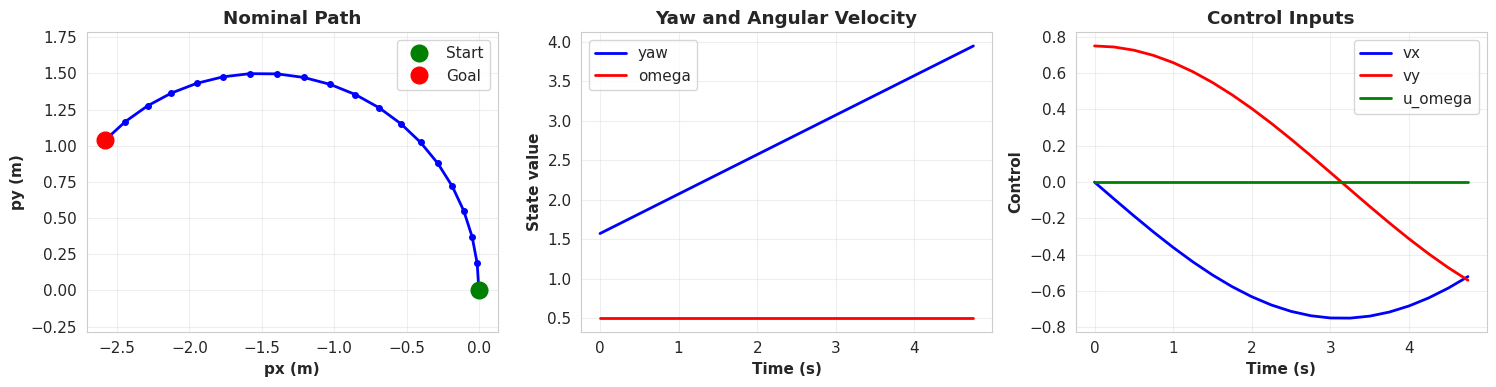

In [6]:
N = 20
dt = 0.25
t = np.linspace(0, (N-1)*dt, N)

# Circular trajectory parameters
radius = 1.5
omega_nom = 0.5  # Constant angular velocity

# Position trajectory
px_nom = radius * np.cos(omega_nom * t) - radius
py_nom = radius * np.sin(omega_nom * t)
yaw_nom = omega_nom * t + np.pi/2
omega_state_nom = np.ones(N) * omega_nom  # Constant angular velocity

x_nom_traj = np.column_stack([px_nom, py_nom, yaw_nom, omega_state_nom])

# Control inputs
vx_nom = -radius * omega_nom * np.sin(omega_nom * t)
vy_nom = radius * omega_nom * np.cos(omega_nom * t)
u_omega_nom = np.zeros(N)  # Zero angular acceleration (constant omega)

u_nom_traj = np.column_stack([vx_nom, vy_nom, u_omega_nom])

print(f"Nominal trajectory:")
print(f"  State dimension: {x_nom_traj.shape[1]} [px, py, yaw, omega]")
print(f"  Control dimension: {u_nom_traj.shape[1]} [vx, vy, u_omega]")
print(f"  Trajectory length: {N} steps")
print(f"  Time horizon: {N*dt:.2f}s")
print(f"  Nominal angular velocity: {omega_nom} rad/s")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Position trajectory
axes[0].plot(px_nom, py_nom, 'b-o', linewidth=2, markersize=4)
axes[0].plot(px_nom[0], py_nom[0], 'go', markersize=12, label='Start')
axes[0].plot(px_nom[-1], py_nom[-1], 'ro', markersize=12, label='Goal')
axes[0].set_xlabel('px (m)', fontweight='bold')
axes[0].set_ylabel('py (m)', fontweight='bold')
axes[0].set_title('Nominal Path', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

# States over time
axes[1].plot(t, yaw_nom, 'b-', linewidth=2, label='yaw')
axes[1].plot(t, omega_state_nom, 'r-', linewidth=2, label='omega')
axes[1].set_xlabel('Time (s)', fontweight='bold')
axes[1].set_ylabel('State value', fontweight='bold')
axes[1].set_title('Yaw and Angular Velocity', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Control inputs
axes[2].plot(t, vx_nom, 'b-', linewidth=2, label='vx')
axes[2].plot(t, vy_nom, 'r-', linewidth=2, label='vy')
axes[2].plot(t, u_omega_nom, 'g-', linewidth=2, label='u_omega')
axes[2].set_xlabel('Time (s)', fontweight='bold')
axes[2].set_ylabel('Control', fontweight='bold')
axes[2].set_title('Control Inputs', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Propagate Fault Scenarios

Compare how the three scenarios evolve under the extended dynamics.

In [7]:
def propagate_scenario_extended(
    x0_int: Interval,
    u_traj: np.ndarray,
    scenario: FaultScenario,
    dt: float
) -> Tuple[List[Interval], List[Interval]]:
    """
    Propagate extended state through fault scenario.
    
    Returns:
        (true_state_history, observed_state_history)
    """
    alpha_int = Interval(
        lower=jnp.array([scenario.alpha_range[0]]),
        upper=jnp.array([scenario.alpha_range[1]])
    )
    
    N = len(u_traj)
    x_current = x0_int
    yaw_error_int = Interval(lower=jnp.array([0.0]), upper=jnp.array([0.0]))
    
    true_history = [x_current]
    observed_history = [x_current]  # Initially no error
    
    for t in range(N - 1):
        u = jnp.array(u_traj[t])
        
        # Propagate true state
        x_current = interval_dynamics_step_extended(x_current, u, alpha_int, dt)
        true_history.append(x_current)
        
        # Apply sensor fault to get observed state
        x_observed, yaw_error_int = apply_gyro_fault_to_state_interval(
            x_current, scenario, dt, yaw_error_int
        )
        observed_history.append(x_observed)
    
    return true_history, observed_history


# Initial state uncertainty
x0_int = Interval(
    lower=jnp.array([-0.03, -0.03, -0.02, -0.01]),
    upper=jnp.array([0.03, 0.03, 0.02, 0.01])
)

print("Initial state interval:")
print(f"  px ∈ [{x0_int.lower[0]:.3f}, {x0_int.upper[0]:.3f}] m")
print(f"  py ∈ [{x0_int.lower[1]:.3f}, {x0_int.upper[1]:.3f}] m")
print(f"  yaw ∈ [{x0_int.lower[2]:.3f}, {x0_int.upper[2]:.3f}] rad")
print(f"  omega ∈ [{x0_int.lower[3]:.3f}, {x0_int.upper[3]:.3f}] rad/s")

# Propagate all scenarios
results = {}
for scenario in scenarios:
    print(f"\nPropagating {scenario.name}...")
    true_hist, obs_hist = propagate_scenario_extended(x0_int, u_nom_traj, scenario, dt)
    results[scenario.name] = {
        'true_history': true_hist,
        'observed_history': obs_hist
    }

print("\n✓ All scenarios propagated")

Initial state interval:
  px ∈ [-0.030, 0.030] m
  py ∈ [-0.030, 0.030] m
  yaw ∈ [-0.020, 0.020] rad
  omega ∈ [-0.010, 0.010] rad/s

Propagating Nominal...

Propagating Sensor Fault...

Propagating Actuator Fault...

✓ All scenarios propagated


## 7. Visualize Results

Show how true state and observed state differ for each fault scenario.

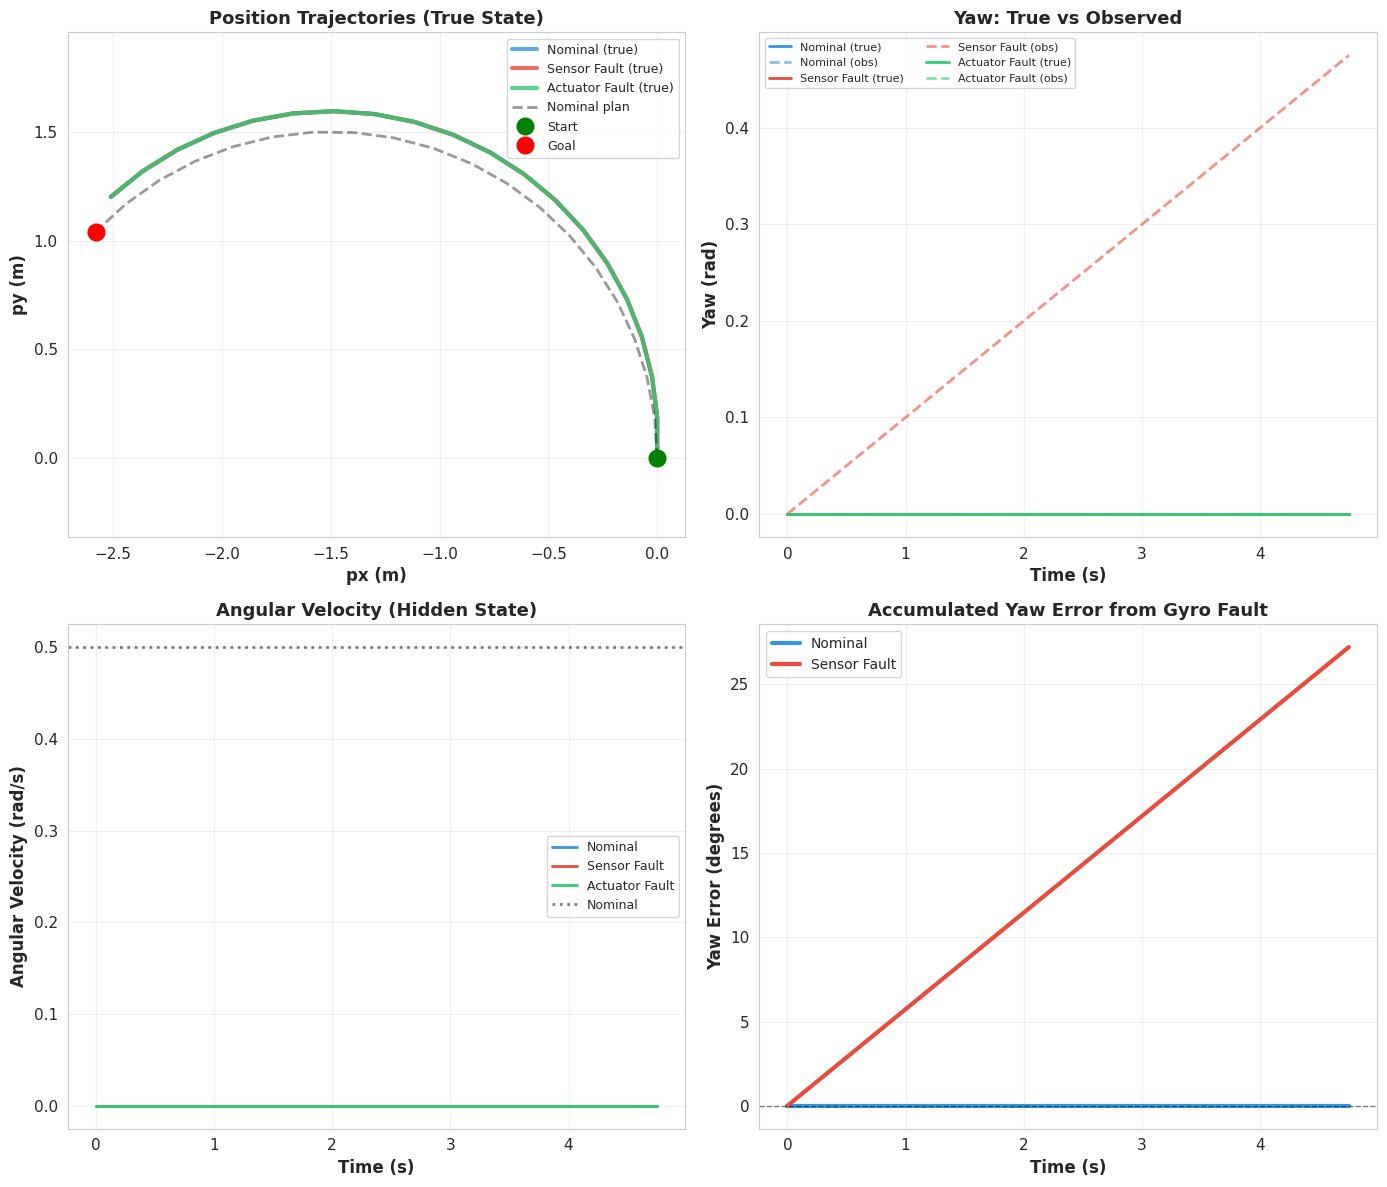


✓ Saved: go2_hidden_angular_velocity_trajectories.pdf


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

colors = {'Nominal': '#3498db', 'Sensor Fault': '#e74c3c', 'Actuator Fault': '#2ecc71'}

# Plot 1: Position trajectories (TRUE state)
ax = axes[0, 0]
for scenario_name, data in results.items():
    true_hist = data['true_history']
    mids = np.array([np.array(h.mid) for h in true_hist])
    ax.plot(mids[:, 0], mids[:, 1], '-', color=colors[scenario_name],
           linewidth=3, label=f'{scenario_name} (true)', alpha=0.8)

ax.plot(px_nom, py_nom, 'k--', linewidth=2, alpha=0.4, label='Nominal plan')
ax.plot(px_nom[0], py_nom[0], 'go', markersize=12, label='Start')
ax.plot(px_nom[-1], py_nom[-1], 'ro', markersize=12, label='Goal')
ax.set_xlabel('px (m)', fontsize=12, fontweight='bold')
ax.set_ylabel('py (m)', fontsize=12, fontweight='bold')
ax.set_title('Position Trajectories (True State)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.axis('equal')

# Plot 2: Yaw evolution (TRUE vs OBSERVED)
ax = axes[0, 1]
for scenario_name, data in results.items():
    true_hist = data['true_history']
    obs_hist = data['observed_history']
    
    true_yaws = np.array([float(h.mid[2]) for h in true_hist])
    obs_yaws = np.array([float(h.mid[2]) for h in obs_hist])
    
    ax.plot(t, true_yaws, '-', color=colors[scenario_name],
           linewidth=2, label=f'{scenario_name} (true)')
    ax.plot(t, obs_yaws, '--', color=colors[scenario_name],
           linewidth=2, alpha=0.6, label=f'{scenario_name} (obs)')

ax.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Yaw (rad)', fontsize=12, fontweight='bold')
ax.set_title('Yaw: True vs Observed', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Plot 3: Angular velocity (TRUE state only)
ax = axes[1, 0]
for scenario_name, data in results.items():
    true_hist = data['true_history']
    omegas = np.array([float(h.mid[3]) for h in true_hist])
    ax.plot(t, omegas, '-', color=colors[scenario_name],
           linewidth=2, label=scenario_name)

ax.axhline(y=omega_nom, color='k', linestyle=':', linewidth=2, alpha=0.5, label='Nominal')
ax.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Angular Velocity (rad/s)', fontsize=12, fontweight='bold')
ax.set_title('Angular Velocity (Hidden State)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Yaw error accumulation (SENSOR FAULT)
ax = axes[1, 1]
for scenario_name in ['Nominal', 'Sensor Fault']:
    data = results[scenario_name]
    true_hist = data['true_history']
    obs_hist = data['observed_history']
    
    true_yaws = np.array([float(h.mid[2]) for h in true_hist])
    obs_yaws = np.array([float(h.mid[2]) for h in obs_hist])
    yaw_error = obs_yaws - true_yaws
    
    ax.plot(t, np.degrees(yaw_error), '-', color=colors[scenario_name],
           linewidth=3, label=scenario_name)

ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Yaw Error (degrees)', fontsize=12, fontweight='bold')
ax.set_title('Accumulated Yaw Error from Gyro Fault', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('go2_hidden_angular_velocity_trajectories.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: go2_hidden_angular_velocity_trajectories.pdf")

## 8. Final Reachable Sets

Compare final position intervals for each scenario.

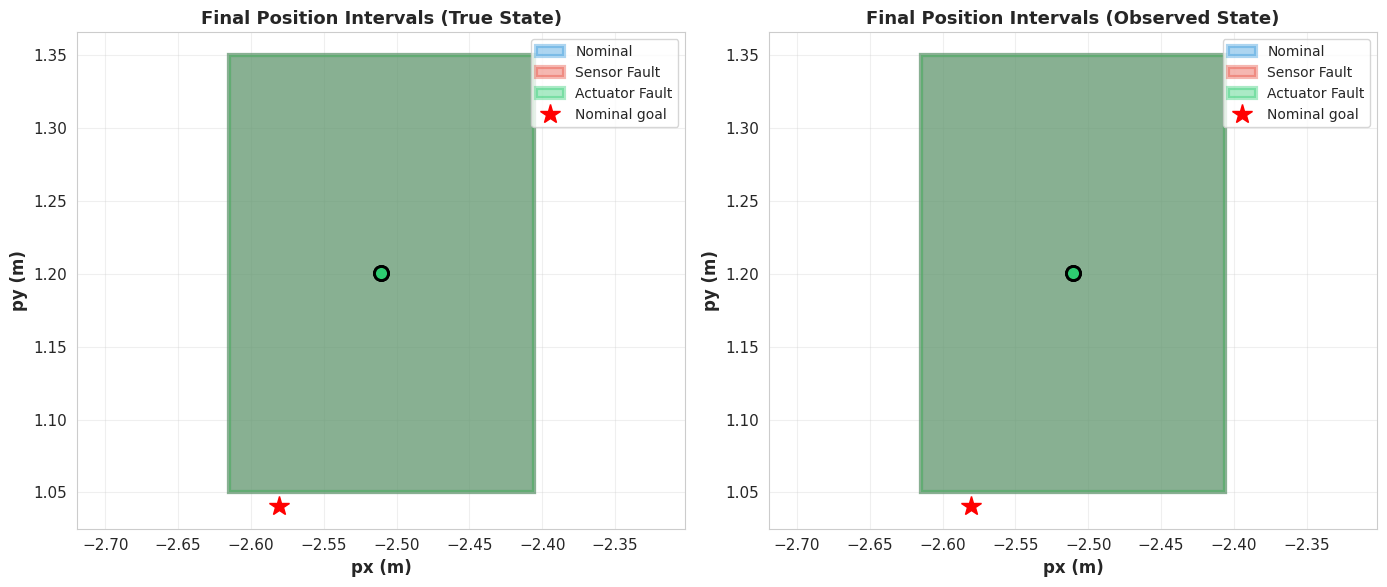


✓ Saved: go2_hidden_angular_velocity_final_intervals.pdf


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Extract final intervals
final_true = {}
final_observed = {}

for scenario_name, data in results.items():
    final_true[scenario_name] = data['true_history'][-1]
    final_observed[scenario_name] = data['observed_history'][-1]

# Plot 1: Final TRUE position intervals
ax = axes[0]
for scenario_name in scenarios:
    x_final = final_true[scenario_name.name]
    px_l, px_u = float(x_final.lower[0]), float(x_final.upper[0])
    py_l, py_u = float(x_final.lower[1]), float(x_final.upper[1])
    
    rect = Rectangle(
        (px_l, py_l),
        px_u - px_l,
        py_u - py_l,
        linewidth=3,
        edgecolor=colors[scenario_name.name],
        facecolor=colors[scenario_name.name],
        alpha=0.4,
        label=scenario_name.name
    )
    ax.add_patch(rect)
    
    # Center point
    cx, cy = (px_l + px_u)/2, (py_l + py_u)/2
    ax.plot(cx, cy, 'o', color=colors[scenario_name.name],
           markersize=10, markeredgecolor='black', markeredgewidth=2)

ax.plot(px_nom[-1], py_nom[-1], 'r*', markersize=15, label='Nominal goal')
ax.set_xlabel('px (m)', fontsize=12, fontweight='bold')
ax.set_ylabel('py (m)', fontsize=12, fontweight='bold')
ax.set_title('Final Position Intervals (True State)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axis('equal')

# Plot 2: Final OBSERVED position intervals
ax = axes[1]
for scenario_name in scenarios:
    x_final = final_observed[scenario_name.name]
    px_l, px_u = float(x_final.lower[0]), float(x_final.upper[0])
    py_l, py_u = float(x_final.lower[1]), float(x_final.upper[1])
    
    rect = Rectangle(
        (px_l, py_l),
        px_u - px_l,
        py_u - py_l,
        linewidth=3,
        edgecolor=colors[scenario_name.name],
        facecolor=colors[scenario_name.name],
        alpha=0.4,
        label=scenario_name.name
    )
    ax.add_patch(rect)
    
    cx, cy = (px_l + px_u)/2, (py_l + py_u)/2
    ax.plot(cx, cy, 'o', color=colors[scenario_name.name],
           markersize=10, markeredgecolor='black', markeredgewidth=2)

ax.plot(px_nom[-1], py_nom[-1], 'r*', markersize=15, label='Nominal goal')
ax.set_xlabel('px (m)', fontsize=12, fontweight='bold')
ax.set_ylabel('py (m)', fontsize=12, fontweight='bold')
ax.set_title('Final Position Intervals (Observed State)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axis('equal')

plt.tight_layout()
plt.savefig('go2_hidden_angular_velocity_final_intervals.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: go2_hidden_angular_velocity_final_intervals.pdf")

## 9. Summary and Key Insights

### Extended System Properties

1. **State Dimension**: 4D `[px, py, yaw, omega]` vs 3D `[px, py, yaw]`
2. **Hidden State**: Angular velocity `omega` is not directly observed
3. **Second-Order Dynamics**: Yaw dynamics are now second-order (omega is the derivative of yaw)

### Sensor Fault Effects

**Gyroscope Fault**: `omega_measured = a * omega_true + b`

- **Scale error** (a ≠ 1): Causes yaw error to accumulate proportional to angular velocity
- **Bias** (b ≠ 0): Causes yaw error to grow linearly with time
- **Combined effect**: `yaw_error(t) = ∫[(a-1)·omega + b]dt`

### Observations from Plots

1. **Position trajectories** (Plot 1): Actuator fault creates distinct path, sensor fault follows nominal
2. **Yaw evolution** (Plot 2): Sensor fault causes divergence between true and observed yaw
3. **Angular velocity** (Plot 3): Actuator fault affects omega, sensor fault doesn't affect true omega
4. **Yaw error accumulation** (Plot 4): Sensor fault shows growing error over time due to integration

### Implications for Fault Diagnosis

**Actuator Faults**:
- ✅ Easily detected via position deviation
- ✅ Directly affects physical trajectory
- ✅ Affects hidden state (omega)

**Sensor Faults (Gyroscope)**:
- ⚠️ Doesn't affect true position (follows nominal path)
- ⚠️ Only detectable through yaw discrepancy
- ✅ Accumulates over time (grows with integration)
- ✅ Can be detected if we compare observed yaw with expected yaw from position

### Comparison with Simple 3D Model

| Aspect | 3D Model | 4D Extended Model |
|--------|----------|-------------------|
| **State** | [px, py, yaw] | [px, py, yaw, omega] |
| **Yaw dynamics** | First-order | Second-order |
| **Sensor fault** | Direct yaw measurement | Gyro → integrated yaw |
| **Error growth** | Instantaneous | Accumulates via integration |
| **Observability** | Full state | omega is hidden |

### Advantages of Extended Model

1. **More realistic**: Separates angular velocity sensing from yaw estimation
2. **Captures integration errors**: Models how gyro bias accumulates
3. **Richer dynamics**: Second-order heading dynamics
4. **Better fault modeling**: Distinguishes between sensor and actuator faults more clearly